# Project — Sales Forecasting using Linear Regression
**Topic:** Linear Regression
**Phases covered:** Phase 1 (Data Collection), Phase 2 (Preprocessing), Phase 3 (Linear Regression modeling)

This notebook goes task-by-task through the checklist in the project document, using the **Sales Forecasting dataset** (Kaggle: rohitsahoo/sales-forecasting).


## Setup — Imports library
Run this once before starting any task.

In [376]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
%matplotlib inline


---
# Step-2  Data Collection

###  Download the Sales Dataset from kaggle
Dataset: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting

Download `train.csv` from Kaggle (you'll need a free Kaggle account and API key, or download manually from the browser) and place it in the same folder as this notebook.


In [377]:
# Load the dataset
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [378]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

---
# Step-3  Data Preprocessing (Sales Dataset)

###  Handle missing values


In [379]:
# Check missing values and duplicate values
print("Duplicate Values:")
print(df.duplicated().sum())
print("\nMissing Values per column :")
print(df.isnull().sum().sort_values(ascending=False).head(10))
# Sales dataset mainly has missing values in 'Postal Code'
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])

Duplicate Values:
0

Missing Values per column :
Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
dtype: int64


In [380]:
# Convert date columns (string to datetime format)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after cleaning:
0


### Feature engineering (needed before regression)
Since the raw dataset has mostly categorical/date fields and only one obvious numeric target (`Sales`), we build a few numeric predictors so the regression tasks below have something meaningful to work with.


In [381]:
print("Category has number of unique values :" ,df["Category"].nunique())
print("Category has number of unique values :" ,df["Sub-Category"].nunique())

Category has number of unique values : 3
Category has number of unique values : 17


In [382]:
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year']  = df['Order Date'].dt.year
df['Ship_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Aggregate to one row per order-line with a couple of numeric drivers
model_df = df[['Sales', 'Order_Month', 'Order_Year', 'Ship_Delay_Days']].copy()

# One-hot encode a categorical driver: Ship Mode, Segment, Region
cat_cols = ['Ship Mode', 'Segment', 'Region'] # Cat and sub cat baad me add ki h 
model_df = pd.concat([model_df, pd.get_dummies(df[cat_cols], drop_first=True)], axis=1)
model_df = model_df.dropna()
model_df.head()


,Sales,Order_Month,Order_Year,Ship_Delay_Days,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,261.9600,11,2017,3,False,True,False,False,False,False,True,False
1,731.9400,11,2017,3,False,True,False,False,False,False,True,False
2,14.6200,6,2017,4,False,True,False,True,False,False,False,True
3,957.5775,10,2016,7,False,False,True,False,False,False,True,False
4,22.3680,10,2016,7,False,False,True,False,False,False,True,False


In [383]:
'''df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year']  = df['Order Date'].dt.year
df['Ship_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Aggregate to one row per order-line with a couple of numeric drivers
model_df = df[['Sales', 'Order_Month', 'Order_Year', 'Ship_Delay_Days']].copy()

# One-hot encode a categorical driver: Ship Mode, Segment, Region
cat_cols = ['Ship Mode', 'Segment', 'Region','Category', 'Sub-Category'] # Cat and sub cat baad me add ki h 
model_df = pd.concat([model_df, pd.get_dummies(df[cat_cols], drop_first=True)], axis=1)
model_df = model_df.dropna()
display(model_df.shape)
display(model_df.head())'''


"df['Order_Month'] = df['Order Date'].dt.month\ndf['Order_Year']  = df['Order Date'].dt.year\ndf['Ship_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days\n\n# Aggregate to one row per order-line with a couple of numeric drivers\nmodel_df = df[['Sales', 'Order_Month', 'Order_Year', 'Ship_Delay_Days']].copy()\n\n# One-hot encode a categorical driver: Ship Mode, Segment, Region\ncat_cols = ['Ship Mode', 'Segment', 'Region','Category', 'Sub-Category'] # Cat and sub cat baad me add ki h \nmodel_df = pd.concat([model_df, pd.get_dummies(df[cat_cols], drop_first=True)], axis=1)\nmodel_df = model_df.dropna()\ndisplay(model_df.shape)\ndisplay(model_df.head())"

### Check for multicollinearity using VIF

In [384]:
X_vif = model_df.drop(columns=['Sales']).astype(float)
X_vif = X_vif.assign(const=1)  # VIF requires a constant term

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)
display(vif_data)


,feature,VIF
5,Ship Mode_Standard Class,3.949953
2,Ship_Delay_Days,3.132378
4,Ship Mode_Second Class,2.014270
10,Region_West,1.620790
8,Region_East,1.595012
3,Ship Mode_Same Day,1.529118
9,Region_South,1.426665
7,Segment_Home Office,1.106699
6,Segment_Corporate,1.105587
0,Order_Month,1.005602


### Remove highly correlated features (VIF > 10)

In [385]:
high_vif_features = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
print("Features to drop (VIF > 10):", high_vif_features)

model_df = model_df.drop(columns=high_vif_features)
display(model_df.shape)
display(model_df.columns)

Features to drop (VIF > 10): []


(9800, 12)

Index(['Sales', 'Order_Month', 'Order_Year', 'Ship_Delay_Days',
       'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office',
       'Region_East', 'Region_South', 'Region_West'],
      dtype='str')

### Split Sales Dataset into train (70%) and test (30%)

In [386]:
X = model_df.drop(columns=['Sales'])
y = model_df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Display dataset sizes after splitting
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (6860, 11)
Testing Features : (2940, 11)
Training Labels : (6860,)
Testing Labels  : (2940,)


---
#  Linear Regression (Sales Forecasting)

###  Perform EDA: Plot sales vs each feature (scatter plots)

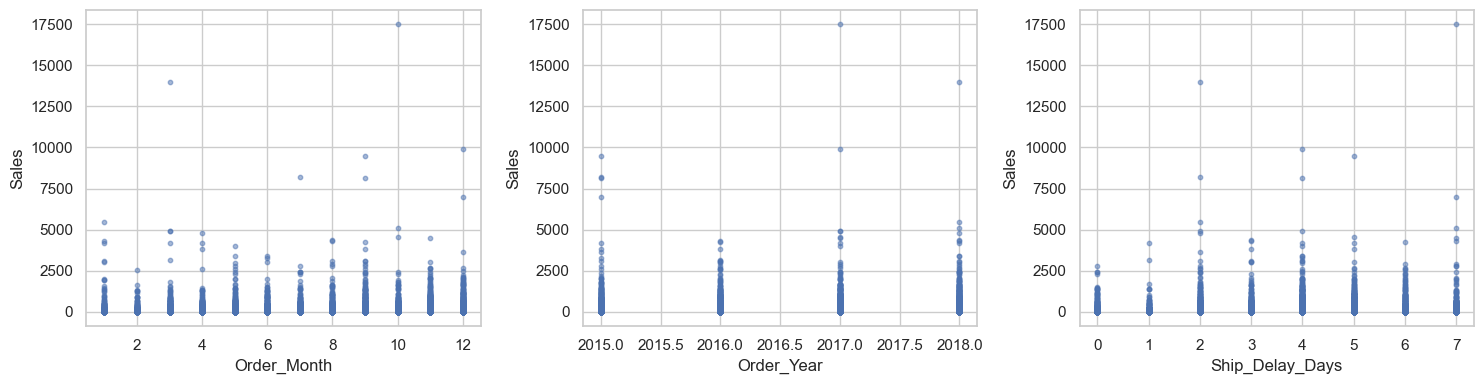

In [387]:
numeric_features = [c for c in X.columns if X[c].nunique() > 2]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(5*len(numeric_features), 4))
if len(numeric_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, numeric_features):
    ax.scatter(X_train[feat], y_train, alpha=0.5, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()


### Check linearity assumption using scatter plots
Look at the scatter plots above: if the point cloud shows a straight-line trend (rather than a curve), the linearity assumption is reasonable. If you see curvature, a polynomial term may be needed (handled in Task 9-11 below).


###  Build a simple Linear Regression model using `LinearRegression` from sklearn


In [388]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0.77, -5.32, 4.98,..., -2.07,-13.43, 6.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['Order_Month','Order_Year','Ship_Delay_Days',...,'Region_East', 'Region_South','Region_West']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.093e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [389]:
print("Model trained.")

Model trained.


In [390]:
#Make predictions on the test set
y_pred_test = lr.predict(X_test)

### Check normality of residuals using Q-Q plot


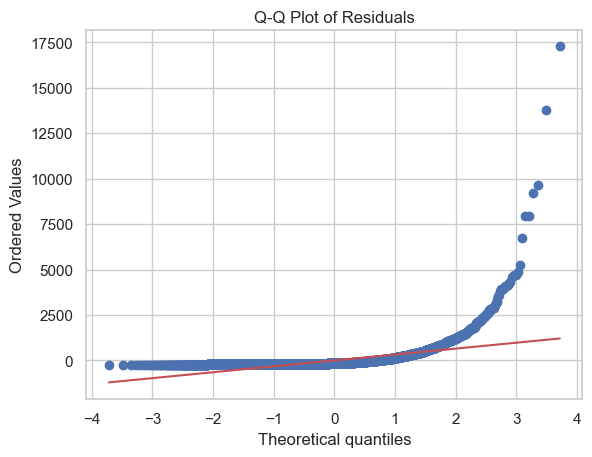

In [391]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
residuals = y_train - y_pred_train

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


### Task 4 — Check homoscedasticity using residual plot

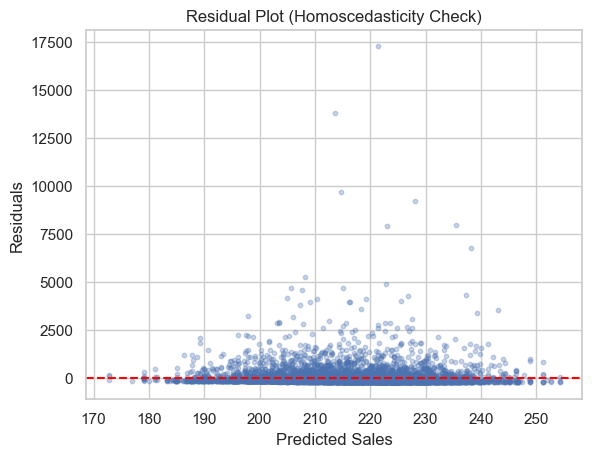

In [392]:
plt.scatter(y_pred_train, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoscedasticity Check)")
plt.show()


### Task 5 — Build a simple Linear Regression model using `LinearRegression` from sklearn
(Already fit above in Task 3, repeated here for clarity as the standalone deliverable for this task.)


In [393]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_test = lr.predict(X_test)
print("Model trained.")


Model trained.


### Task 6 — Evaluate model using R², RMSE

In [394]:
r2 = r2_score(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)   #mean_squared_error

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")


R²   : -0.0060
RMSE : 782.9935


### Task 7 — Plot actual vs predicted sales

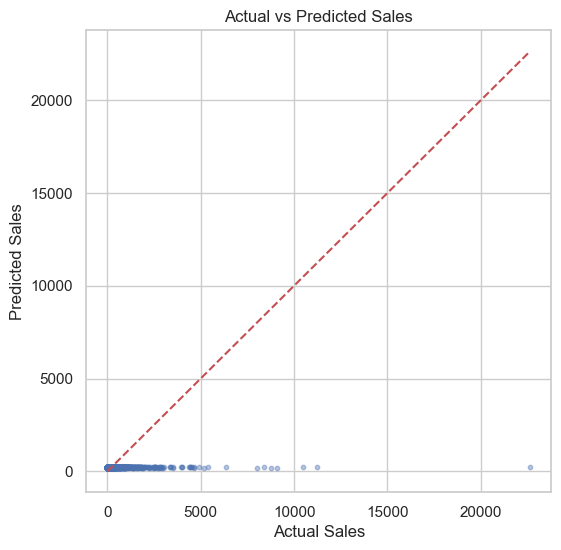

In [395]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


### Task 8 — Interpret coefficients (business meaning)

In [396]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df)

# Example interpretation (edit based on your actual output):
# A positive coefficient on 'Ship_Delay_Days' would mean each extra day of
# shipping delay is associated with a rise in sales value of that magnitude,
# holding other features constant — useful for spotting whether slower
# shipping correlates with bigger (bulkier/heavier) orders.


                     Feature  Coefficient
10               Region_West     6.800355
2            Ship_Delay_Days     4.978519
4     Ship Mode_Second Class     2.867909
0                Order_Month     0.766764
8                Region_East    -2.066670
3         Ship Mode_Same Day    -3.916065
7        Segment_Home Office    -4.840824
1                 Order_Year    -5.321540
6          Segment_Corporate    -6.714270
9               Region_South   -13.434793
5   Ship Mode_Standard Class   -14.241712


### Task 9 — Add interaction terms and polynomial features (`PolynomialFeatures`)

In [397]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original features:", X_train.shape[1])
print("Polynomial features (deg=2):", X_train_poly.shape[1])

Original features: 11
Polynomial features (deg=2): 77


### Task 10 — Build Polynomial Regression model (degree=2, 3)

In [ ]:
results_poly = {}

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train)
    X_test_p  = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_p, y_train)
    pred = model.predict(X_test_p)

    results_poly[degree] = {
        'R2': r2_score(y_test, pred),
        'RMSE': root_mean_squared_error(y_test, pred)  # RMSE
    }

results_poly


{2: {'R2': -0.009381341596489401, 'RMSE': 784.2975786639306},
 3: {'R2': -0.00986862351061446, 'RMSE': 784.4868668431544}}

### Task 11 — Compare performance of polynomial regression vs linear

In [399]:
comparison = pd.DataFrame({
    'Model': ['Linear', 'Poly (deg 2)', 'Poly (deg 3)'],
    'R2':   [r2, results_poly[2]['R2'], results_poly[3]['R2']],
    'RMSE': [rmse, results_poly[2]['RMSE'], results_poly[3]['RMSE']]
})
print(comparison)


          Model        R2        RMSE
0        Linear -0.006028  782.993542
1  Poly (deg 2) -0.009381  784.297579
2  Poly (deg 3) -0.009869  784.486867


### Task 12 — Use Ridge regression and tune alpha parameter

In [400]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = {}

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)
    ridge_scores[a] = r2_score(y_test, pred)

best_alpha_ridge = max(ridge_scores, key=ridge_scores.get)
print("Ridge R² by alpha:", ridge_scores)
print("Best alpha (Ridge):", best_alpha_ridge)


Ridge R² by alpha: {0.01: -0.006027556335838069, 0.1: -0.0060273891249704725, 1: -0.006025720330603779, 10: -0.006009354678940371, 100: -0.005871061662861887}
Best alpha (Ridge): 100


### Task 13 — Use Lasso regression and tune alpha parameter

In [401]:
lasso_scores = {}

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    pred = lasso.predict(X_test)
    lasso_scores[a] = r2_score(y_test, pred)

best_alpha_lasso = max(lasso_scores, key=lasso_scores.get)
print("Lasso R² by alpha:", lasso_scores)
print("Best alpha (Lasso):", best_alpha_lasso)


Lasso R² by alpha: {0.01: -0.006013628351211109, 0.1: -0.005889223391543519, 1: -0.005053779931240898, 10: -0.004313842081005159, 100: -0.004313842081005159}
Best alpha (Lasso): 10


### Task 14 — Compare Linear, Ridge, and Lasso regression results

In [402]:
final_ridge = Ridge(alpha=best_alpha_ridge).fit(X_train, y_train)
final_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train, y_train)

comparison_final = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R2': [
        r2_score(y_test, lr.predict(X_test)),
        r2_score(y_test, final_ridge.predict(X_test)),
        r2_score(y_test, final_lasso.predict(X_test)),
    ],
    'RMSE': [
        root_mean_squared_error(y_test, lr.predict(X_test)), #, squared=False
        root_mean_squared_error(y_test, final_ridge.predict(X_test)), #, squared=False
        root_mean_squared_error(y_test, final_lasso.predict(X_test)), #, squared=False
    ]
})
print(comparison_final)


               Model        R2        RMSE
0  Linear Regression -0.006028  782.993542
1              Ridge -0.005871  782.932633
2              Lasso -0.004314  782.326357


### Task 15 — Perform cross-validation (5-fold) for all models

In [403]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=best_alpha_ridge),
    'Lasso': Lasso(alpha=best_alpha_lasso, max_iter=10000)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    cv_results[name] = (scores.mean(), scores.std())

for name, (mean_r2, std_r2) in cv_results.items():
    print(f"{name}: mean R² = {mean_r2:.4f} (+/- {std_r2:.4f})")


Linear: mean R² = -0.0052 (+/- 0.0027)
Ridge: mean R² = -0.0050 (+/- 0.0025)
Lasso: mean R² = -0.0031 (+/- 0.0017)


---
## Summary

- Data was cleaned, encoded, and checked for multicollinearity (VIF).
- A baseline Linear Regression model was built, evaluated (R², RMSE), and its assumptions (linearity, normal residuals, homoscedasticity) were checked visually.
- Polynomial features (degree 2 & 3) were tested against the plain linear model.
- Ridge and Lasso regression were tuned over a range of alpha values and compared to the linear baseline.
- 5-fold cross-validation confirmed which model generalizes best.

**Note:** Replace `train.csv` with your actual downloaded Kaggle file, and adjust `cat_cols` / feature engineering if your column names differ.
